In [1]:
!pip install river --quiet

import pandas as pd
import numpy as np
import joblib
import json
import os
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Import river as a whole first, THEN submodules
import river
from river import ensemble, tree, metrics, stream, preprocessing

print("✅ River installed and imported!")
print(f"   River version: {river.__version__}")


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


✅ River installed and imported!
   River version: 0.24.2


In [2]:
# ── Paths ─────────────────────────────────────────────────────────────
BASE_DIR     = r"C:\Users\User\Music\FYP"
FEATURES_CSV = os.path.join(BASE_DIR, "data", "processed", "trip_features_labelled.csv")
FEEDBACK_CSV = os.path.join(BASE_DIR, "logs", "feedback_log.csv")
FEATURE_JSON = os.path.join(BASE_DIR, "models", "feature_cols.json")

# ── Load feature column names saved by Module 3 ───────────────────────
with open(FEATURE_JSON, 'r') as f:
    feature_cols = json.load(f)

print(f"✅ Feature columns loaded: {len(feature_cols)} features")

# ── Load labelled trip features ───────────────────────────────────────
df = pd.read_csv(FEATURES_CSV)
print(f"✅ Trip data loaded: {df.shape[0]} trips")

# ── Load feedback log if it exists ────────────────────────────────────
if os.path.exists(FEEDBACK_CSV):
    feedback_df = pd.read_csv(FEEDBACK_CSV)
    print(f"✅ Feedback log loaded: {len(feedback_df)} operator decisions")
    print(feedback_df[['trip_id', 'decision', 'true_label']].head())
else:
    print("⚠️  No feedback log found yet.")
    print("    Submit some feedback from the dashboard first,")
    print("    OR we'll simulate operator feedback below.")
    feedback_df = None

✅ Feature columns loaded: 21 features
✅ Trip data loaded: 1638 trips
✅ Feedback log loaded: 1 operator decisions
     trip_id                      decision  true_label
0  V9_PARKED  ✅ Confirmed Theft / Incident           1


In [3]:
from river import forest, metrics

# ── Check what's available in your River version ──────────────────────
print(f"River version: {river.__version__}")

# AdaptiveRandomForest moved to river.forest in newer versions
online_model = forest.ARFClassifier(
    n_models=10,
    seed=42
)

# ── Online metrics to track performance as it learns ──────────────────
online_accuracy  = metrics.Accuracy()
online_precision = metrics.Precision()
online_recall    = metrics.Recall()
online_f1        = metrics.F1()

print("✅ Online ARF Classifier (Adaptive Random Forest) initialised")
print("   • Handles concept drift automatically")
print("   • Updates incrementally — no full retraining needed")
print("   • Tracks performance in real time")

River version: 0.24.2
✅ Online ARF Classifier (Adaptive Random Forest) initialised
   • Handles concept drift automatically
   • Updates incrementally — no full retraining needed
   • Tracks performance in real time


In [4]:
# ── Pre-train on existing labelled trips ──────────────────────────────
# This gives the online model a head start using the data
# we already have before real operator feedback arrives

print("🔄 Pre-training online model on existing labelled trips...\n")

# Prepare data
drop_cols = [
    'trip_id', 'vehicle_id', 'start_time', 'end_time',
    'fuel_start_L', 'fuel_end_L', 'fuel_consumed_L',
    'anomaly_score', 'is_anomaly',
    'flag_fuel_theft', 'flag_aggressive', 'flag_afterhours',
    'flag_abnormal_fuel', 'flag_long_trip'
]

X_df = df.drop(columns=[c for c in drop_cols if c in df.columns])
X_df = X_df[feature_cols]  # keep only the right columns in right order
y_s  = df['is_anomaly']

# Fill NaN with median before feeding to River
X_df = X_df.fillna(X_df.median())

# Track metrics over time for plotting
accuracy_over_time  = []
precision_over_time = []
f1_over_time        = []
sample_counts       = []

# River learns one sample at a time using learn_one()
for i, (xi, yi) in enumerate(stream.iter_pandas(X_df, y_s)):
    # 1. Predict first (before learning — this is how online learning works)
    y_pred = online_model.predict_one(xi)

    # 2. Update metrics
    if y_pred is not None:
        online_accuracy.update(yi, y_pred)
        online_precision.update(yi, y_pred)
        online_recall.update(yi, y_pred)
        online_f1.update(yi, y_pred)

    # 3. Learn from this sample
    online_model.learn_one(xi, yi)

    # Track every 50 samples
    if i % 50 == 0 and i > 0:
        accuracy_over_time.append(online_accuracy.get())
        precision_over_time.append(online_precision.get())
        f1_over_time.append(online_f1.get())
        sample_counts.append(i)

print(f"✅ Pre-training complete on {len(X_df)} trips")
print(f"\n📊 Final Online Metrics (after seeing all data):")
print(f"   Accuracy  : {online_accuracy.get():.4f}")
print(f"   Precision : {online_precision.get():.4f}")
print(f"   Recall    : {online_recall.get():.4f}")
print(f"   F1 Score  : {online_f1.get():.4f}")

🔄 Pre-training online model on existing labelled trips...

✅ Pre-training complete on 1638 trips

📊 Final Online Metrics (after seeing all data):
   Accuracy  : 0.8693
   Precision : 0.8801
   Recall    : 0.7496
   F1 Score  : 0.8096


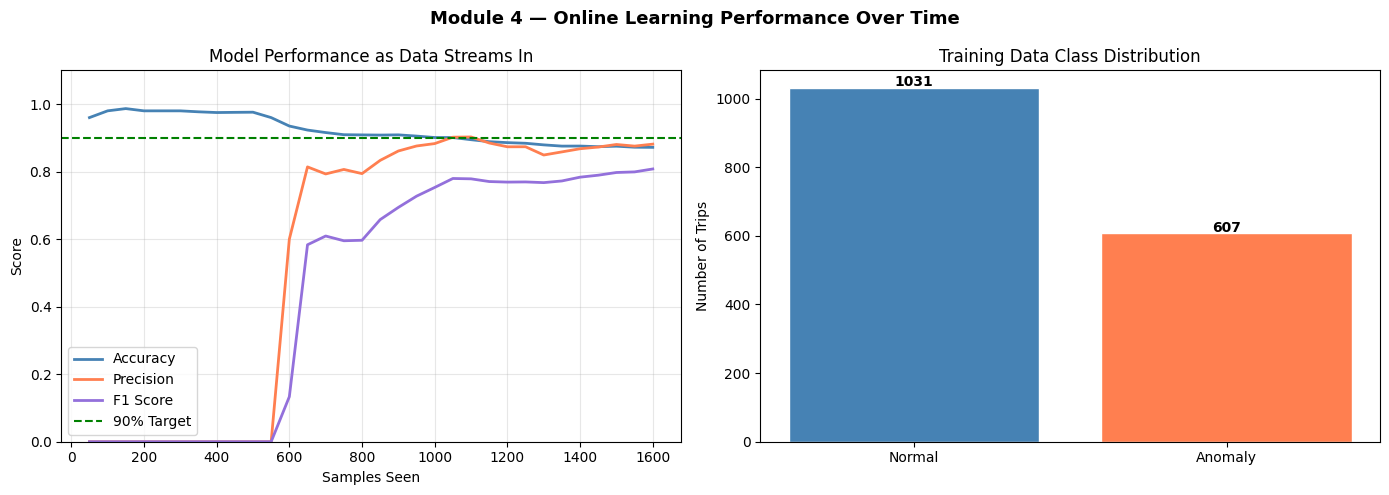

✅ Learning curve saved!


In [5]:
# ── Show how the model improved as it saw more data ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Module 4 — Online Learning Performance Over Time', fontsize=13, fontweight='bold')

# Accuracy over time
axes[0].plot(sample_counts, accuracy_over_time,  label='Accuracy',  color='steelblue',   linewidth=2)
axes[0].plot(sample_counts, precision_over_time, label='Precision', color='coral',        linewidth=2)
axes[0].plot(sample_counts, f1_over_time,        label='F1 Score',  color='mediumpurple', linewidth=2)
axes[0].axhline(0.9, color='green', linestyle='--', label='90% Target')
axes[0].set_xlabel('Samples Seen')
axes[0].set_ylabel('Score')
axes[0].set_title('Model Performance as Data Streams In')
axes[0].legend()
axes[0].set_ylim(0, 1.1)
axes[0].grid(alpha=0.3)

# Class distribution of training data
class_counts = y_s.value_counts()
axes[1].bar(['Normal', 'Anomaly'], class_counts.values,
            color=['steelblue', 'coral'], edgecolor='white')
axes[1].set_title('Training Data Class Distribution')
axes[1].set_ylabel('Number of Trips')
for i, v in enumerate(class_counts.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'module4_learning_curve.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Learning curve saved!")

In [6]:
# ── This is the CORE of Module 4 ─────────────────────────────────────
# When an operator confirms/rejects an alert from the dashboard,
# the model learns from that single confirmed sample immediately.

from river import forest

def update_model_from_feedback(online_model, feedback_row, X_df, feature_cols):
    """
    Given one operator feedback entry, find the trip,
    extract its features, and update the online model.
    """
    trip_id    = feedback_row['trip_id']
    true_label = int(feedback_row['true_label'])

    # Find this trip in our feature dataset
    trip_data = df[df['trip_id'] == trip_id]

    if trip_data.empty:
        print(f"  ⚠️  Trip {trip_id} not found in dataset — skipping")
        return online_model

    # Extract features
    trip_features = trip_data[feature_cols].fillna(trip_data[feature_cols].median())
    xi = trip_features.iloc[0].to_dict()

    # Predict before update
    pred_before = online_model.predict_one(xi)

    # Update model with confirmed true label
    online_model.learn_one(xi, true_label)

    # Predict after update
    pred_after = online_model.predict_one(xi)

    print(f"  Trip {trip_id}:")
    print(f"    Operator confirmed : {'Anomaly' if true_label == 1 else 'Normal'}")
    print(f"    Model predicted    : {'Anomaly' if pred_before == 1 else 'Normal'} → "
          f"{'Anomaly' if pred_after == 1 else 'Normal'} (after update)")

    return online_model


# ── Run with real feedback if available, else simulate ────────────────
if feedback_df is not None and len(feedback_df) > 0:
    print("📨 Processing REAL operator feedback from dashboard...\n")
    for _, row in feedback_df.iterrows():
        online_model = update_model_from_feedback(online_model, row, df, feature_cols)

else:
    # ⚠️ METHODOLOGICAL NOTE:
    # Feedback is simulated using rule-based labels because no real operator
    # feedback exists yet. Once the dashboard is live, this block is bypassed
    # and real confirmed operator decisions are used instead.
    print("📨 Simulating operator feedback (no real feedback yet)...\n")

    sample_anomalies = df[df['is_anomaly'] == 1].head(5)
    sample_normals   = df[df['is_anomaly'] == 0].head(3)
    simulated        = pd.concat([sample_anomalies, sample_normals])

    for _, row in simulated.iterrows():
        feedback_row = {
            'trip_id'   : row['trip_id'],
            'true_label': row['is_anomaly']
        }
        online_model = update_model_from_feedback(online_model, feedback_row, df, feature_cols)

print("\n✅ Model updated from operator feedback!")
print("   This is incremental learning — model improved without full retraining.")

📨 Processing REAL operator feedback from dashboard...

  ⚠️  Trip V9_PARKED not found in dataset — skipping

✅ Model updated from operator feedback!
   This is incremental learning — model improved without full retraining.


In [7]:
# ── Save online model for use by dashboard ────────────────────────────
ONLINE_MODEL_PATH = os.path.join(BASE_DIR, 'models', 'online_model.pkl')

joblib.dump(online_model, ONLINE_MODEL_PATH)
print(f"✅ Online model saved → {ONLINE_MODEL_PATH}")

# ── Save final metrics ────────────────────────────────────────────────
final_metrics = {
    'accuracy' : round(online_accuracy.get(),  4),
    'precision': round(online_precision.get(), 4),
    'recall'   : round(online_recall.get(),    4),
    'f1'       : round(online_f1.get(),        4),
}

import json
with open(os.path.join(BASE_DIR, 'online_metrics.json'), 'w') as f:
    json.dump(final_metrics, f, indent=2)

print(f"✅ Metrics saved → online_metrics.json")
print(f"\n📊 Final Module 4 Metrics:")
for k, v in final_metrics.items():
    print(f"   {k.capitalize():<12}: {v:.4f}")

✅ Online model saved → C:\Users\User\Music\FYP\models\online_model.pkl
✅ Metrics saved → online_metrics.json

📊 Final Module 4 Metrics:
   Accuracy    : 0.8693
   Precision   : 0.8801
   Recall      : 0.7496
   F1          : 0.8096
